# Machine Learing

## Train Test Split

In [1]:
import pandas as pd 

In [2]:
dataset = pd.read_csv('Boston.csv')

In [3]:
dataset.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
dataset.shape

(506, 15)

In [5]:
input_data = dataset.iloc[:,:-1]
output_data = dataset.iloc[:, -1]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.25)

In [8]:
x_train.shape, y_train.shape

((379, 14), (379,))

In [9]:
x_test.shape, y_test.shape

((127, 14), (127,))

## Regression Analysis

In [10]:
car_dataset = pd.read_csv('car data.csv')

In [11]:
car_dataset.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [12]:
car_dataset = car_dataset.iloc[:,[0,1,3,4,5,6,7,8,2]]
car_dataset

,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Selling_Price
0,ritz,2014,5.59,27000,Petrol,Dealer,Manual,0,3.35
1,sx4,2013,9.54,43000,Diesel,Dealer,Manual,0,4.75
2,ciaz,2017,9.85,6900,Petrol,Dealer,Manual,0,7.25
3,wagon r,2011,4.15,5200,Petrol,Dealer,Manual,0,2.85
4,swift,2014,6.87,42450,Diesel,Dealer,Manual,0,4.60
...,...,...,...,...,...,...,...,...,...
296,city,2016,11.60,33988,Diesel,Dealer,Manual,0,9.50
297,brio,2015,5.90,60000,Petrol,Dealer,Manual,0,4.00
298,city,2009,11.00,87934,Petrol,Dealer,Manual,0,3.35
299,city,2017,12.50,9000,Diesel,Dealer,Manual,0,11.50


In [13]:
placement_data = pd.read_csv("package.csv")
placement_data.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [14]:
placement_data.isnull().sum()

cgpa       0
package    0
dtype: int64

In [15]:
x = placement_data[['cgpa']]
y = placement_data['package']
x.ndim

2

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns 

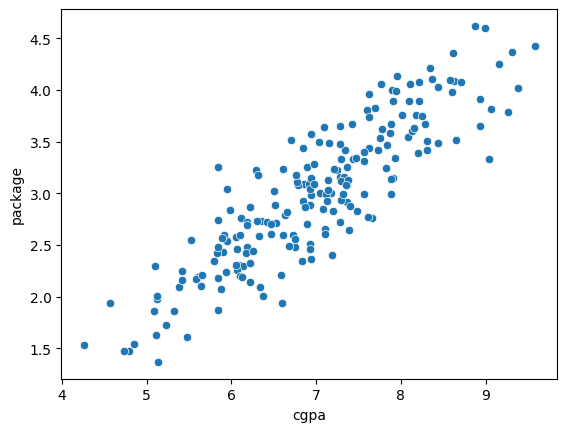

In [17]:
sns.scatterplot(x="cgpa", y="package", data=placement_data)
plt.show()

In [18]:
x_train_new, x_test_new, y_train_new, y_test_new = train_test_split(x, y, test_size=0.2, random_state=42)

### Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lr = LinearRegression()
lr.fit(x_train_new, y_train_new)

LinearRegression()

In [21]:
lr.score(x_test_new,y_test_new)

0.7730984312051673

In [22]:
lr.predict([[6.89]])

c:\Users\iamha\anaconda3\envs\tf-jupyter\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.92962016])

In [23]:
lr.coef_

array([0.57425647])

In [24]:
lr.intercept_

np.float64(-1.0270069374542108)

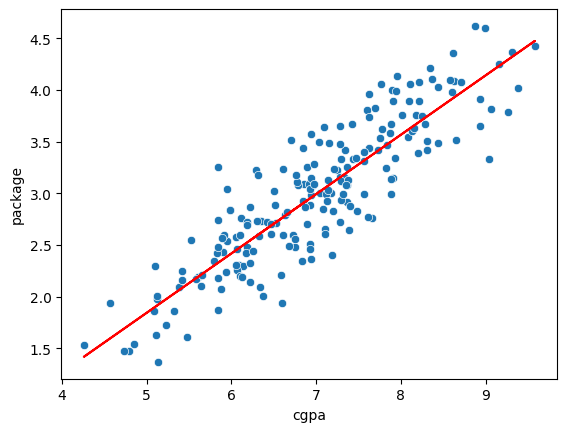

In [25]:
sns.scatterplot(x="cgpa", y="package", data=placement_data)
plt.plot(placement_data['cgpa'], lr.predict(x),c="red")
plt.show()

### Mulitple Linear Regression -> Simiar to Simple Linear Regression 

In [26]:
iq_data = pd.read_csv('IQ.csv')
iq_data.head()

,CGPA,IQ,package
0,6.8,123,3.26
1,5.9,106,1.98
2,5.3,121,3.25
3,7.4,132,3.67
4,5.8,142,3.57


In [27]:
iq_data.shape

(100, 3)

In [28]:
iq_data.isnull().sum()

CGPA       0
IQ         0
package    0
dtype: int64

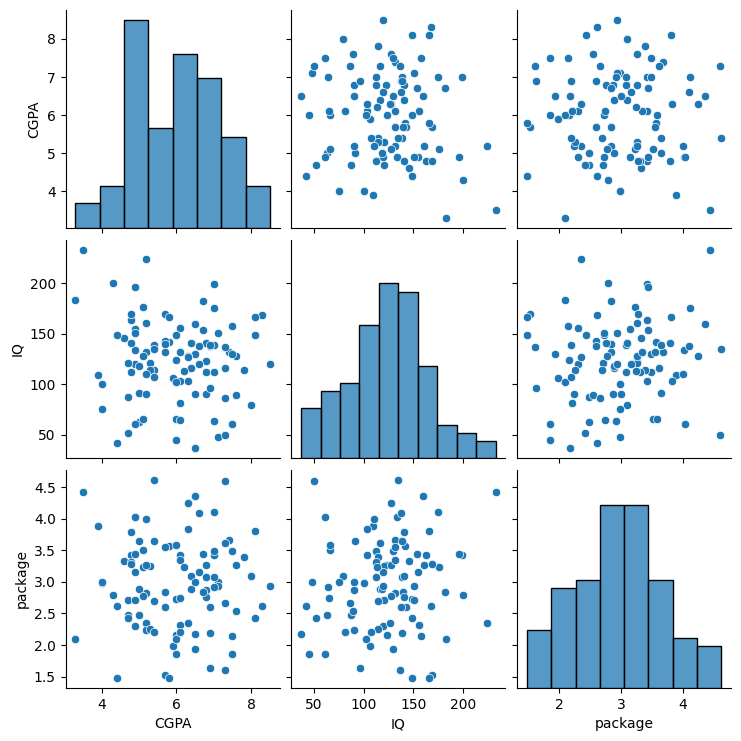

In [29]:
sns.pairplot(data=iq_data)
plt.show()

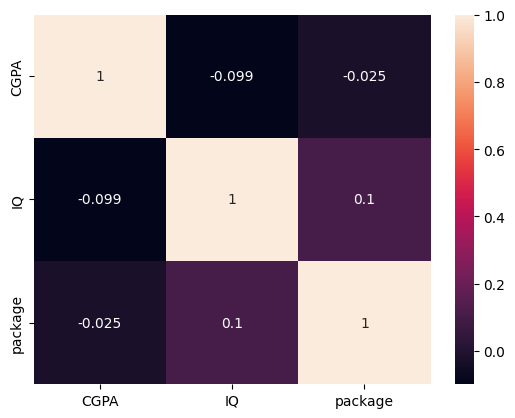

In [30]:
sns.heatmap(data=iq_data.corr(), annot=True)
plt.show()

### Polynomial Regression -> 

In [31]:
from sklearn.preprocessing import PolynomialFeatures

In [32]:
pf = PolynomialFeatures(degree=2)
# pf.fit(x)

## Cost Function

### Regression Cost Function

In [33]:
# Regularization -> Improve 
house_data = pd.read_csv("House_Price.csv")
house_data.head()

,parks,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,price
0,0.049347,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,YES,5.480,11.1920,River,23,YES,24.0
1,0.046146,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,NO,7.332,12.1728,Lake,42,YES,21.6
2,0.045764,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,NO,7.394,101.1200,NaN,38,YES,34.7
3,0.047151,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,YES,9.268,11.2672,Lake,45,YES,33.4
4,0.039474,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,NO,8.824,11.2896,Lake,55,YES,36.2


In [34]:
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 

In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [36]:
house_data['airport'] = le.fit_transform(house_data['airport'])
house_data.head()

,parks,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,price
0,0.049347,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,1,5.480,11.1920,River,23,YES,24.0
1,0.046146,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,0,7.332,12.1728,Lake,42,YES,21.6
2,0.045764,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,0,7.394,101.1200,NaN,38,YES,34.7
3,0.047151,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,1,9.268,11.2672,Lake,45,YES,33.4
4,0.039474,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,0,8.824,11.2896,Lake,55,YES,36.2


In [37]:
house_data['bus_ter'] = le.fit_transform(house_data['bus_ter'])
house_data.head()

,parks,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,price
0,0.049347,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,1,5.480,11.1920,River,23,0,24.0
1,0.046146,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,0,7.332,12.1728,Lake,42,0,21.6
2,0.045764,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,0,7.394,101.1200,NaN,38,0,34.7
3,0.047151,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,1,9.268,11.2672,Lake,45,0,33.4
4,0.039474,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,0,8.824,11.2896,Lake,55,0,36.2


In [38]:
house_data['waterbody'].unique()

array(['River', 'Lake', nan, 'Lake and River'], dtype=object)

In [39]:
house_data['waterbody'].isnull().sum()

np.int64(155)

In [40]:
house_data['waterbody'].fillna(value=house_data['waterbody'].mode()[0], inplace=True)
house_data['waterbody'].isnull().sum()

C:\Users\iamha\AppData\Local\Temp\ipykernel_1668\1369411451.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  house_data['waterbody'].fillna(value=house_data['waterbody'].mode()[0], inplace=True)


np.int64(0)

In [41]:
waterbody_en = pd.get_dummies(house_data['waterbody'], prefix="waterbody", dtype=int)
waterbody_en.head()

,waterbody_Lake,waterbody_Lake and River,waterbody_River
0,0,0,1
1,1,0,0
2,0,0,1
3,1,0,0
4,1,0,0


In [42]:
house_data = pd.concat([house_data, waterbody_en], axis=1)
house_data.head()

,parks,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,...,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,price,waterbody_Lake,waterbody_Lake and River,waterbody_River
0,0.049347,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,...,1,5.480,11.1920,River,23,0,24.0,0,0,1
1,0.046146,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,...,0,7.332,12.1728,Lake,42,0,21.6,1,0,0
2,0.045764,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,...,0,7.394,101.1200,River,38,0,34.7,0,0,1
3,0.047151,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,...,1,9.268,11.2672,Lake,45,0,33.4,1,0,0
4,0.039474,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,...,0,8.824,11.2896,Lake,55,0,36.2,1,0,0


In [43]:
house_data.drop("waterbody", axis=1, inplace=True)
house_data.head()

,parks,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,...,poor_prop,airport,n_hos_beds,n_hot_rooms,rainfall,bus_ter,price,waterbody_Lake,waterbody_Lake and River,waterbody_River
0,0.049347,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,...,4.98,1,5.480,11.1920,23,0,24.0,0,0,1
1,0.046146,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,...,9.14,0,7.332,12.1728,42,0,21.6,1,0,0
2,0.045764,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,...,4.03,0,7.394,101.1200,38,0,34.7,0,0,1
3,0.047151,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,...,2.94,1,9.268,11.2672,45,0,33.4,1,0,0
4,0.039474,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,...,5.33,0,8.824,11.2896,55,0,36.2,1,0,0


In [44]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   parks                     506 non-null    float64
 1   crime_rate                506 non-null    float64
 2   resid_area                506 non-null    float64
 3   air_qual                  506 non-null    float64
 4   room_num                  506 non-null    float64
 5   age                       506 non-null    float64
 6   dist1                     506 non-null    float64
 7   dist2                     506 non-null    float64
 8   dist3                     506 non-null    float64
 9   dist4                     506 non-null    float64
 10  teachers                  506 non-null    float64
 11  poor_prop                 506 non-null    float64
 12  airport                   506 non-null    int64  
 13  n_hos_beds                498 non-null    float64
 14  n_hot_room

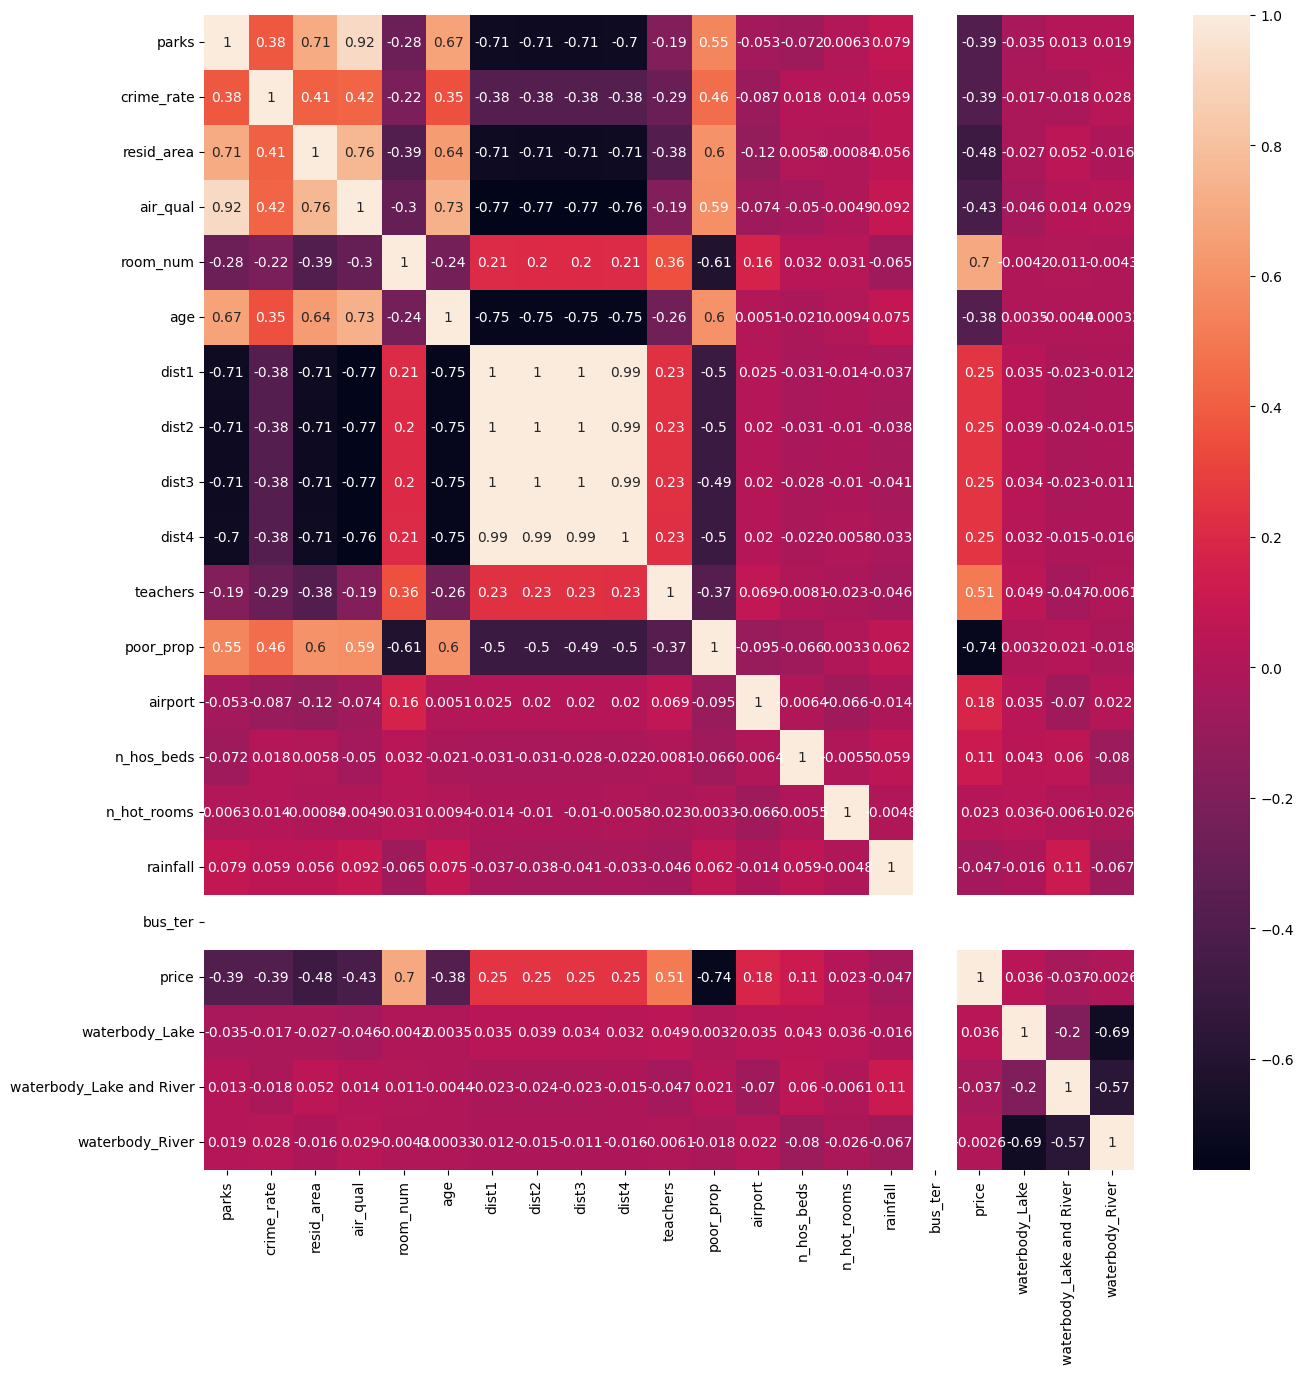

In [45]:
plt.figure(figsize=(15,15))
sns.heatmap(data=house_data.corr(), annot=True)
plt.show()

In [46]:
price_pop = house_data.pop("price")
house_data['price'] = price_pop
house_data.head()

,parks,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,...,poor_prop,airport,n_hos_beds,n_hot_rooms,rainfall,bus_ter,waterbody_Lake,waterbody_Lake and River,waterbody_River,price
0,0.049347,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,...,4.98,1,5.480,11.1920,23,0,0,0,1,24.0
1,0.046146,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,...,9.14,0,7.332,12.1728,42,0,1,0,0,21.6
2,0.045764,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,...,4.03,0,7.394,101.1200,38,0,0,0,1,34.7
3,0.047151,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,...,2.94,1,9.268,11.2672,45,0,1,0,0,33.4
4,0.039474,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,...,5.33,0,8.824,11.2896,55,0,1,0,0,36.2


In [47]:
x = house_data.iloc[:,:-1]
y = house_data.iloc[:,-1]

In [48]:
sc = StandardScaler()

In [49]:
sc.fit(x)
x = pd.DataFrame(sc.transform(x), columns=x.columns)
x

,parks,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,rainfall,bus_ter,waterbody_Lake,waterbody_Lake and River,waterbody_River
0,-0.480763,-0.419782,-1.287909,-0.144217,0.413672,-0.120013,0.179451,0.086032,0.103569,0.186459,1.459000,-1.075562,0.902009,-1.640299,-0.353398,-1.294408,0.0,-0.486995,-0.404003,0.705012
1,-0.782183,-0.417339,-0.593381,-0.740262,0.194274,0.367166,0.483280,0.508534,0.547446,0.687144,0.303094,-0.492439,-1.108637,-0.384875,-0.166000,0.225431,0.0,2.053411,-0.404003,-1.418416
2,-0.818115,-0.417342,-0.593381,-0.740262,1.282714,-0.265812,0.502269,0.584490,0.495503,0.644228,0.303094,-1.208727,-1.108637,-0.342847,16.828839,-0.094535,0.0,-0.486995,-0.404003,0.705012
3,-0.687571,-0.416750,-1.306878,-0.835284,1.016303,-0.809889,1.062454,1.092442,1.038545,1.116302,-0.113032,-1.361517,0.902009,0.927490,-0.339029,0.465405,0.0,2.053411,-0.404003,-1.418416
4,-1.410280,-0.412482,-1.306878,-0.835284,1.228577,-0.511180,1.038717,1.059212,1.137709,1.068618,-0.113032,-1.026501,-1.108637,0.626514,-0.334750,1.265320,0.0,2.053411,-0.404003,-1.418416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.146086,-0.413229,0.115738,0.158124,0.439316,0.018673,-0.632342,-0.559590,-0.566969,-0.743385,-1.176466,-0.418147,-1.108637,0.981720,-0.164777,-0.974442,0.0,-0.486995,2.475229,-1.418416
502,0.513037,-0.415249,0.115738,0.158124,-0.234548,0.288933,-0.727289,-0.720996,-0.708632,-0.705237,-1.176466,-0.500850,0.902009,-0.872945,0.023538,-1.534383,0.0,-0.486995,2.475229,-1.418416
503,0.293573,-0.413447,0.115738,0.158124,0.984960,0.797449,-0.774762,-0.744732,-0.788908,-0.781532,-1.176466,-0.983048,-1.108637,-1.641654,-0.162484,-0.654476,0.0,-0.486995,-0.404003,0.705012
504,0.587494,-0.407764,0.115738,0.158124,0.725672,0.736996,-0.679816,-0.626051,-0.736965,-0.624174,-1.176466,-0.865302,0.902009,0.027273,0.407812,0.625388,0.0,-0.486995,-0.404003,0.705012


In [50]:
x_train_house , x_test_house, y_train_house, y_test_house = train_test_split(x,y,test_size=0.2,random_state=42)

In [51]:
x_train_house.isnull().sum()

parks                       0
crime_rate                  0
resid_area                  0
air_qual                    0
room_num                    0
age                         0
dist1                       0
dist2                       0
dist3                       0
dist4                       0
teachers                    0
poor_prop                   0
airport                     0
n_hos_beds                  7
n_hot_rooms                 0
rainfall                    0
bus_ter                     0
waterbody_Lake              0
waterbody_Lake and River    0
waterbody_River             0
dtype: int64

In [52]:
x_train_house['n_hos_beds'].fillna(x_train_house['n_hos_beds'].mode()[0], inplace=True)
x_train_house.isnull().sum()

C:\Users\iamha\AppData\Local\Temp\ipykernel_1668\4091968029.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train_house['n_hos_beds'].fillna(x_train_house['n_hos_beds'].mode()[0], inplace=True)


parks                       0
crime_rate                  0
resid_area                  0
air_qual                    0
room_num                    0
age                         0
dist1                       0
dist2                       0
dist3                       0
dist4                       0
teachers                    0
poor_prop                   0
airport                     0
n_hos_beds                  0
n_hot_rooms                 0
rainfall                    0
bus_ter                     0
waterbody_Lake              0
waterbody_Lake and River    0
waterbody_River             0
dtype: int64

In [53]:
x_test_house.isnull().sum()

parks                       0
crime_rate                  0
resid_area                  0
air_qual                    0
room_num                    0
age                         0
dist1                       0
dist2                       0
dist3                       0
dist4                       0
teachers                    0
poor_prop                   0
airport                     0
n_hos_beds                  1
n_hot_rooms                 0
rainfall                    0
bus_ter                     0
waterbody_Lake              0
waterbody_Lake and River    0
waterbody_River             0
dtype: int64

In [54]:
x_test_house['n_hos_beds'].fillna(x_test_house['n_hos_beds'].mode()[0], inplace=True)
x_test_house.isnull().sum()

C:\Users\iamha\AppData\Local\Temp\ipykernel_1668\3120253074.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_test_house['n_hos_beds'].fillna(x_test_house['n_hos_beds'].mode()[0], inplace=True)


parks                       0
crime_rate                  0
resid_area                  0
air_qual                    0
room_num                    0
age                         0
dist1                       0
dist2                       0
dist3                       0
dist4                       0
teachers                    0
poor_prop                   0
airport                     0
n_hos_beds                  0
n_hot_rooms                 0
rainfall                    0
bus_ter                     0
waterbody_Lake              0
waterbody_Lake and River    0
waterbody_River             0
dtype: int64

In [55]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge 

In [56]:
lr = LinearRegression()

In [57]:
lr.fit(x_train_house, y_train_house)
lr.score(x_test_house, y_test_house)*100

64.93831884772038

In [58]:
lr.coef_

array([ 4.04389629e-01, -8.68329320e-01, -1.71427865e-01, -2.02674749e+00,
        3.19858305e+00, -3.52845770e-01,  2.98006660e-01,  1.55224777e+00,
       -2.95322981e+00, -1.67733363e+00,  1.92038701e+00, -3.88989805e+00,
        4.97062673e-01,  4.95496033e-01,  1.22048758e-01,  3.51955603e-01,
       -6.66133815e-16,  2.55188999e-01, -2.21732321e-01, -4.97756316e-02])

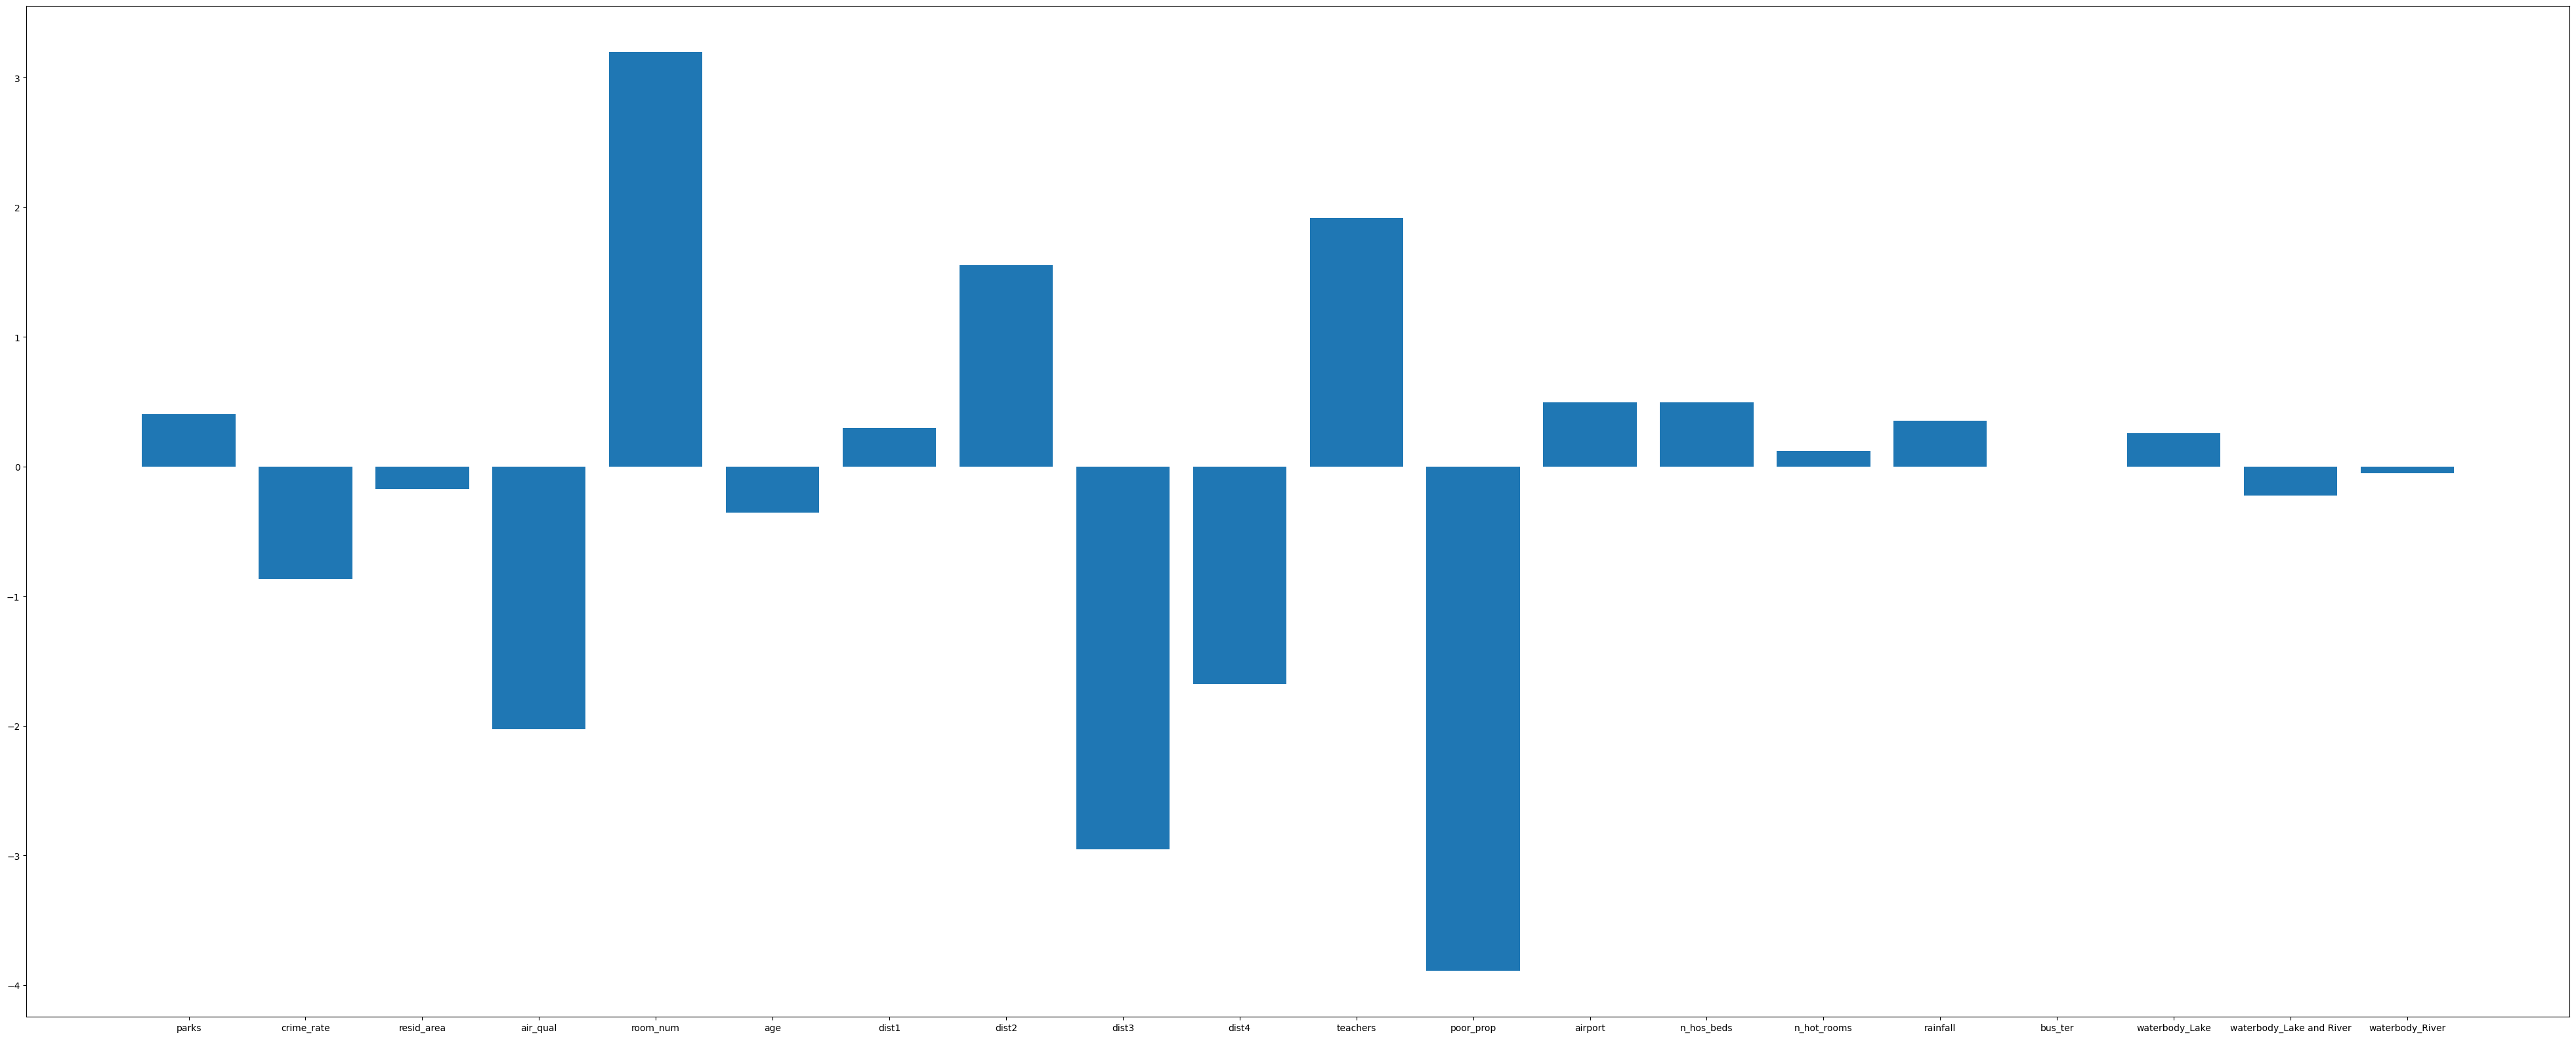

In [59]:
plt.figure(figsize=(50,20))
plt.bar(x.columns, lr.coef_)
plt.show()

#### Lasso

In [60]:
la = Lasso(alpha=0.01)
la.fit(x_train_house, y_train_house)
la.score(x_test_house, y_test_house)

0.6493564931702245

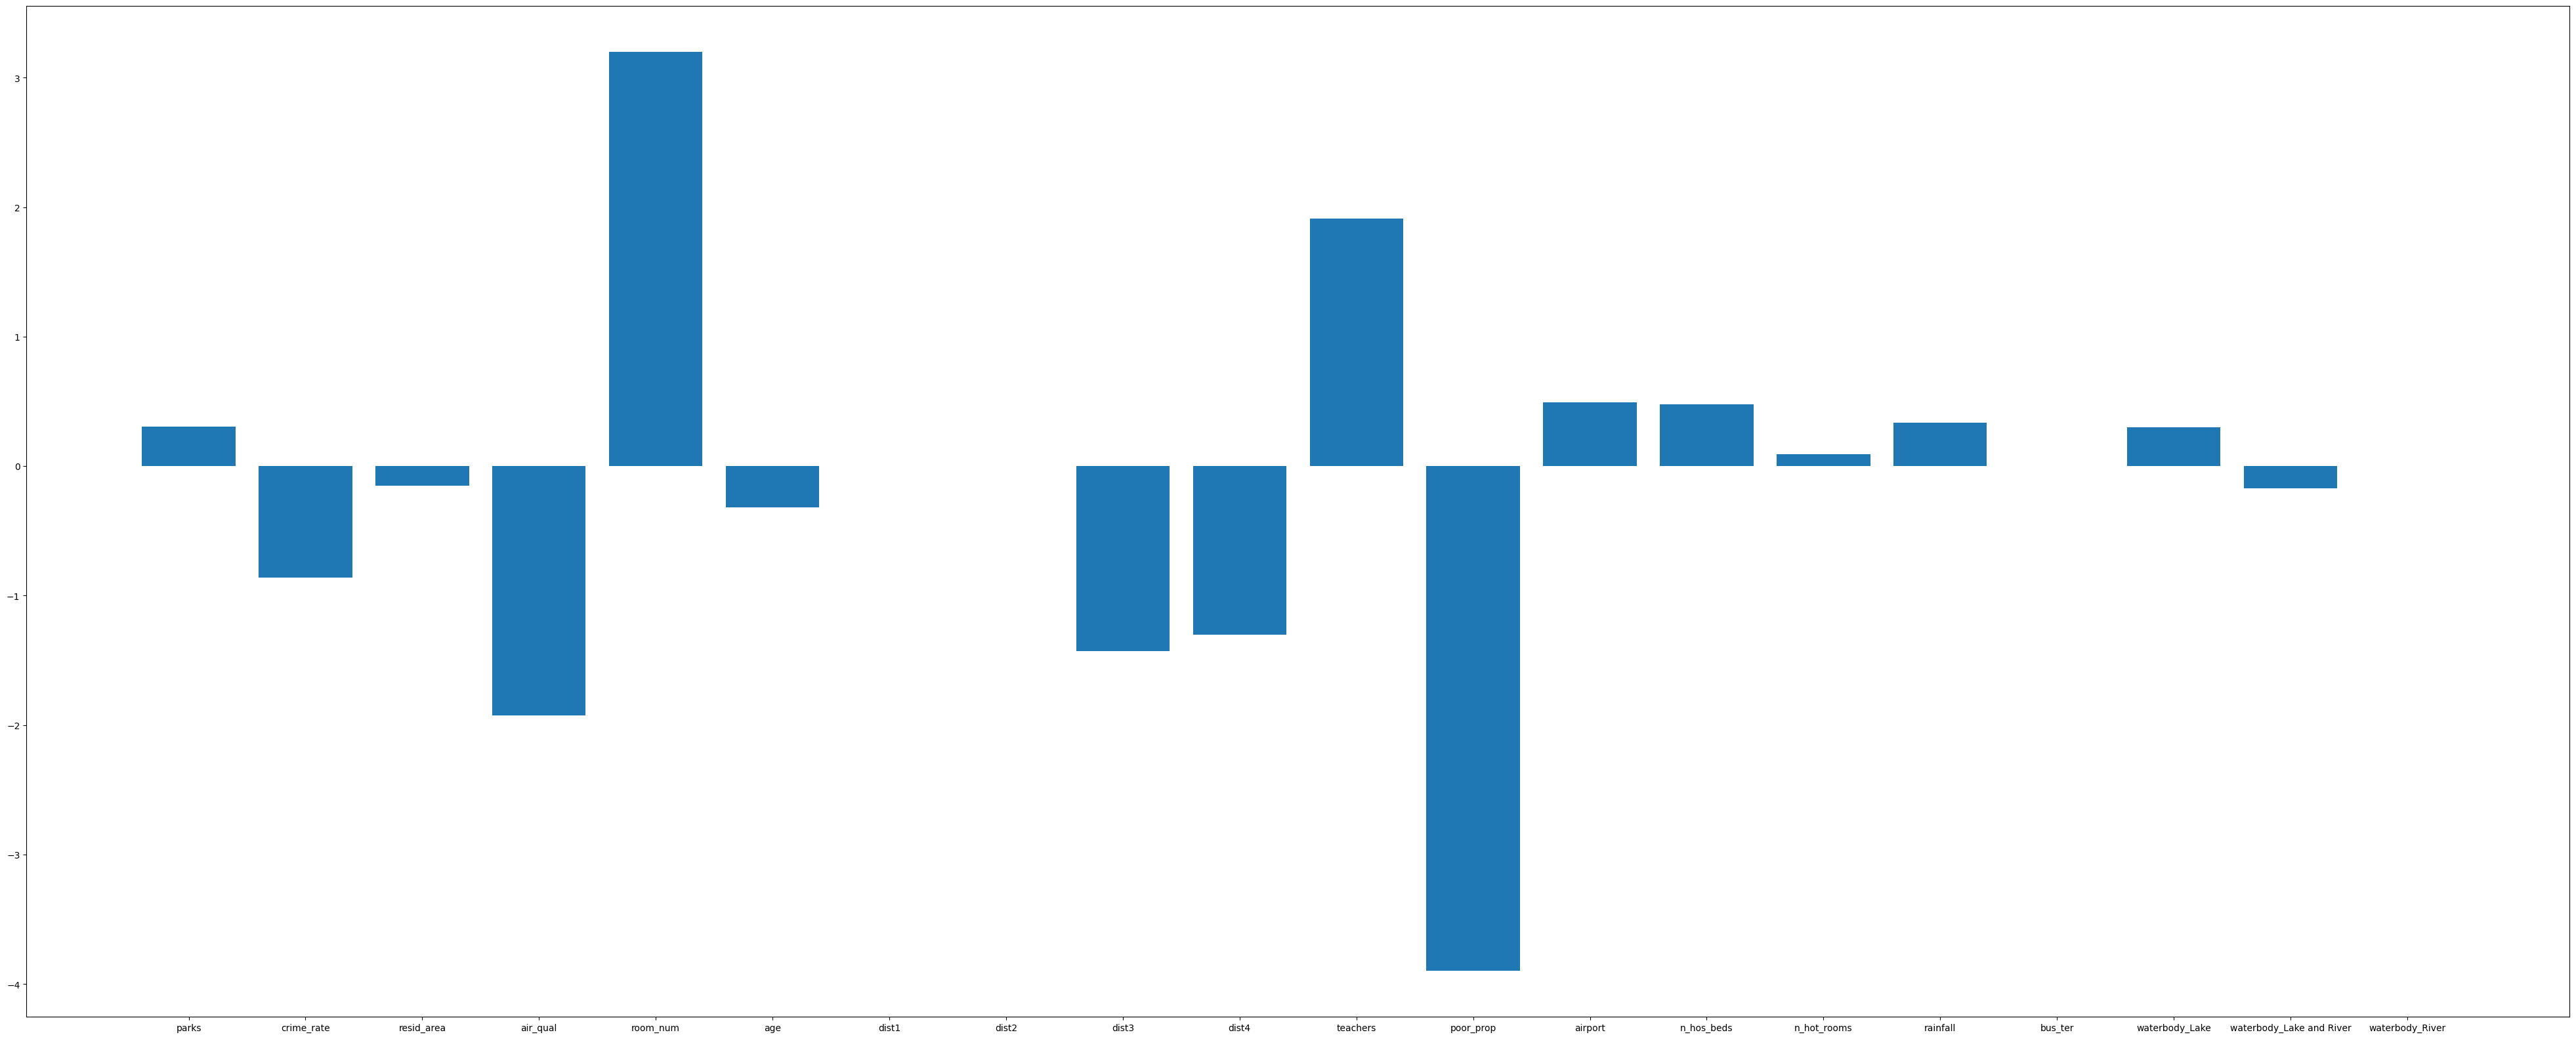

In [61]:
plt.figure(figsize=(50,20))
plt.bar(x.columns, la.coef_)
plt.show()

#### Ridge

In [62]:
ri = Ridge(alpha=140)

In [63]:
ri.fit(x_train_house, y_train_house)
ri.score(x_test_house, y_test_house)*100

66.44483164391812

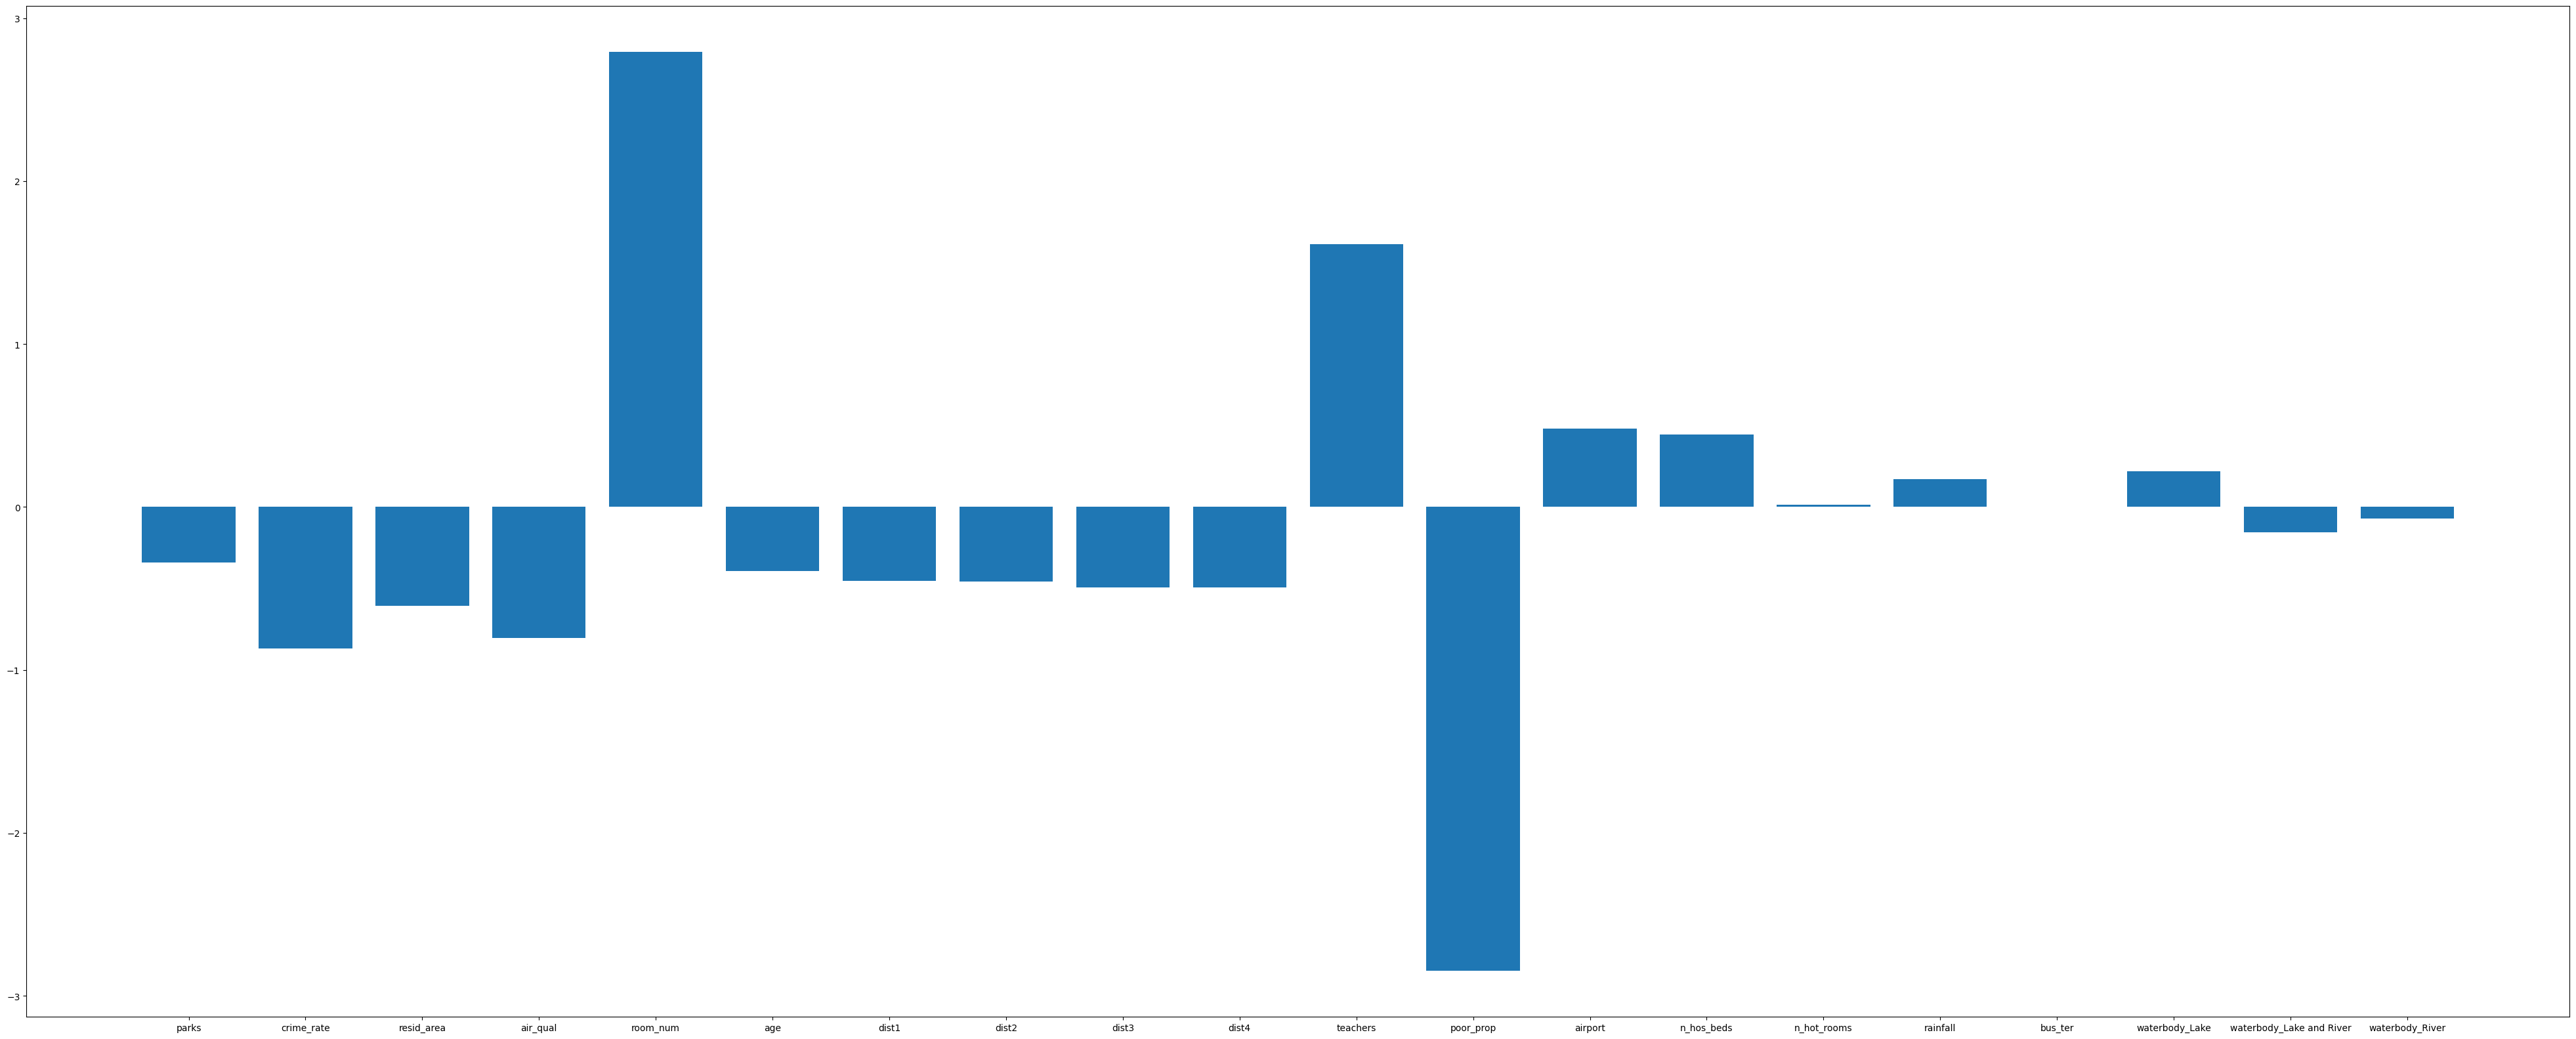

In [64]:
plt.figure(figsize=(50,20))
plt.bar(x.columns, ri.coef_)
plt.show()

## Metrics

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error 
import numpy as np

In [66]:
print(mean_squared_error(y_test_house, lr.predict(x_test_house)))
print(mean_absolute_error(y_test_house, lr.predict(x_test_house)))
print(np.sqrt(mean_squared_error(y_test_house, lr.predict(x_test_house))))

25.85597761126181
3.3481200299507594
5.084877344760816


In [67]:
print(mean_squared_error(y_test_house, la.predict(x_test_house)))
print(mean_absolute_error(y_test_house, la.predict(x_test_house)))
print(np.sqrt(mean_squared_error(y_test_house, la.predict(x_test_house))))

25.85794623694346
3.3538741952092685
5.085070917592345


In [68]:
print(mean_squared_error(y_test_house, ri.predict(x_test_house)))
print(mean_absolute_error(y_test_house, ri.predict(x_test_house)))
print(np.sqrt(mean_squared_error(y_test_house, ri.predict(x_test_house))))

24.74501088492627
3.2803287834068415
4.9744357353298145


In [69]:
pd.DataFrame({"col_name": x.columns, "LR": lr.coef_, "LA":la.coef_, "RI":ri.coef_})

,col_name,LR,LA,RI
0,parks,4.043896e-01,0.304577,-0.341019
1,crime_rate,-8.683293e-01,-0.859110,-0.867559
2,resid_area,-1.714279e-01,-0.152071,-0.605047
3,air_qual,-2.026747e+00,-1.925367,-0.804993
4,room_num,3.198583e+00,3.198697,2.792583
5,age,-3.528458e-01,-0.321246,-0.391812
6,dist1,2.980067e-01,-0.000000,-0.452841
7,dist2,1.552248e+00,-0.000000,-0.455829
8,dist3,-2.953230e+00,-1.430065,-0.493030
9,dist4,-1.677334e+00,-1.299771,-0.492286
